In [1]:
import pandas as pd
df1 = pd.read_csv('co_occurrence_JD_skills_cluster.csv')
df2 = pd.read_csv('co_occurrence_skills_embedd_cluster.csv')

In [5]:
cspa_matrix = pd.DataFrame(columns= df1.columns)
for col in df1.columns:
    for row in df1.index:
        cspa_matrix.at[row, col] = df1.at[row, col] + df2.at[row, col]

In [6]:
cspa_matrix

,Python,R,SQL,Java,Scala,C,C++,Javascript,Matlab,"Julia, Ruby",...,Creativity.1,Problemsolving,Critical thinking,Project management.2,Stakeholder management,Customer service,Presentation skills.1,Writing skills,Public speaking.1,Networking.1
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,2.0
1039,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,2.0,1.0,0.0,0.0,1.0,2.0,1.0,1.0,0.0
1040,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1041,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,2.0,1.0


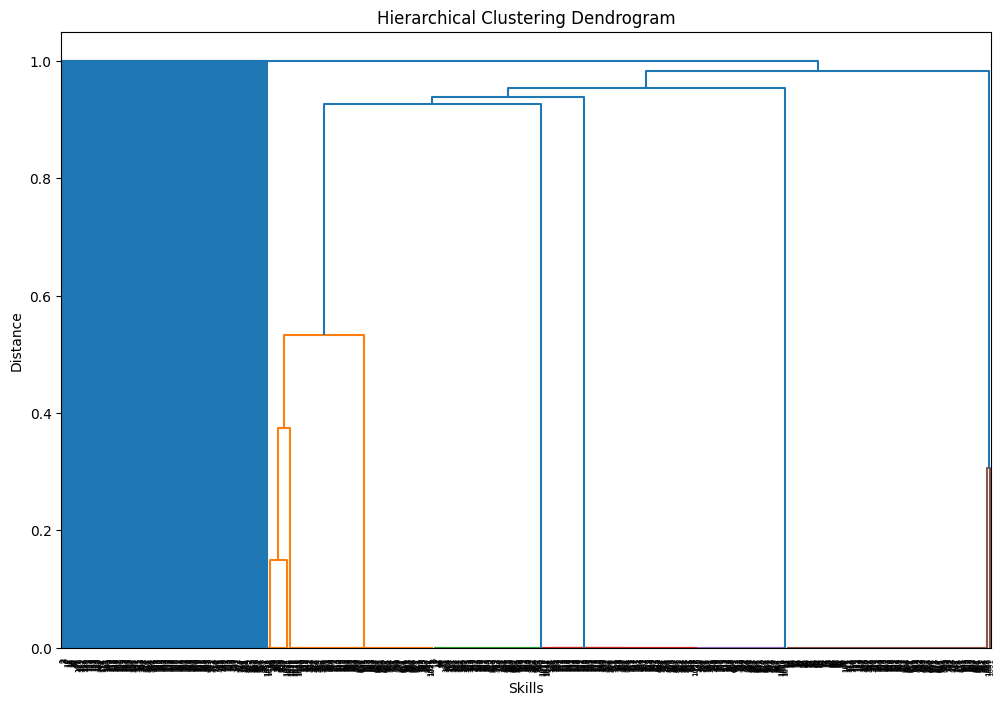

In [8]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import numpy as np

# Convert to distance matrix
distances = 1 - cspa_matrix.values  # Assuming cspa_matrix is a similarity matrix, convert to distance
np.fill_diagonal(distances, 0)  # Ensure diagonal elements are zero

# Ensure distances are non-negative (just a precaution)
distances[distances < 0] = 0

# Perform hierarchical clustering
linkage_matrix = hierarchy.linkage(squareform(distances), method='average')

# Plot dendrogram
plt.figure(figsize=(12, 8))
dendrogram = hierarchy.dendrogram(linkage_matrix, labels=cspa_matrix.index, orientation='top', distance_sort='descending')
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Skills')
plt.ylabel('Distance')
plt.show()

In [13]:
import pandas as pd
from sklearn.cluster import KMeans

# Example frequency threshold for selecting skills
frequency_threshold = 20

# Select skills with frequency above the threshold
high_frequency_skills = cspa_matrix.index[cspa_matrix.sum(axis=1) > frequency_threshold]

# Check if any skills meet the threshold
if len(high_frequency_skills) == 0:
    print("No skills meet the frequency threshold.")
else:
    # Subset the co-occurrence matrix for high frequency skills
    subset_cspa_matrix = cspa_matrix.loc[high_frequency_skills, high_frequency_skills]

# # Subset the co-occurrence matrix for high frequency skills
# subset_cspa_matrix = cspa_matrix.loc[high_frequency_skills, high_frequency_skills]
print(subset_cspa_matrix)
# Perform clustering on the subset matrix
kmeans = KMeans(n_clusters=10, random_state=0)  # Adjust number of clusters as needed
cluster_labels = kmeans.fit_predict(subset_cspa_matrix)

# Example: Print cluster sizes to understand distribution
cluster_sizes = pd.Series(cluster_labels).value_counts()
print("Cluster sizes:")
print(cluster_sizes)

# Example: Visualize or further analyze the clustering results
# Example: Plotting or additional cluster analysis can be done here


KeyError: "None of [Index([   5,    7,    8,    9,   12,   13,   14,   21,   22,   23,\n       ...\n       1033, 1034, 1035, 1036, 1037, 1038, 1039, 1040, 1041, 1042],\n      dtype='int64', length=812)] are in the [columns]"